In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.multicomp import pairwise_tukeyhsd

sys.path.append('./modules')
df = pd.read_csv('../data/01-interim/epcg23_interim_cleaned.csv', low_memory = False)

In [2]:
## Load EDA1 DF + Filter 
df_eda1 = df.copy()

label_map = {
    1: 'Computer/Math Science',
    2: 'Bio/Agricultural/Life Science',
    3: 'Physical & Related Science',
    4: 'Social & Related Science',
    5: 'Engineering',
    6: 'Science & Engineering Related',
    7: 'Non-Science & Engineering'
}

# Filter out Logical Skip and apply
df_eda1 = df_eda1[df_eda1['NBAMEMG'] < 8]
df_eda1 = df_eda1[df_eda1['N2OCPRMG'] < 8]
df_eda1['Major_Category'] = df_eda1['NBAMEMG'].map(label_map)
df_eda1['Job_Category'] = df_eda1['N2OCPRMG'].map(label_map)

In [3]:
## Load EDA2 + Map
df_eda2 = df.copy()

df_eda2['Major_Category'] = df_eda2['NBAMEMG'].map(label_map)
df_eda2 = df_eda2[df_eda2['Major_Category'].notna() & df_eda2['SALARY'].notna()].copy()

## 1. Skewness Check: justify Kruskal-Wallis over ANOVA
skew_vals = df_eda2.groupby('Major_Category')['SALARY'].apply(lambda x: x.skew())
print(f"Skewness per major group: {skew_vals.round(2)}")

Skewness per major group: Major_Category
Bio/Agricultural/Life Science    2.80
Computer/Math Science            5.00
Engineering                      0.83
Non-Science & Engineering        9.18
Physical & Related Science       1.51
Science & Engineering Related    0.73
Social & Related Science         7.29
Name: SALARY, dtype: float64


In [4]:
## 2. Kruskal-Wallis Test
groups = [g['SALARY'].values for _, g in df_eda2.groupby('Major_Category')]
h_stat, p_val = stats.kruskal(*groups)
print(f"Kruskal-Wallis: H = {h_stat: .2f}, p = {p_val: .4e}")

Kruskal-Wallis: H =  2023.19, p =  0.0000e+00


In [5]:
## 3. Tukey HSD post-hoc
tukey = pairwise_tukeyhsd(
    endog = df_eda2['SALARY'],
    groups = df_eda2['Major_Category'],
    alpha = 0.05
)
print("\nTukey HSD Post-Hoc Results:")
print(tukey.summary())


Tukey HSD Post-Hoc Results:
                             Multiple Comparison of Means - Tukey HSD, FWER=0.05                             
            group1                        group2              meandiff  p-adj     lower       upper    reject
-------------------------------------------------------------------------------------------------------------
Bio/Agricultural/Life Science         Computer/Math Science  43734.4166    0.0  38584.6184  48884.2147   True
Bio/Agricultural/Life Science                   Engineering  35474.5285    0.0  30885.7796  40063.2775   True
Bio/Agricultural/Life Science     Non-Science & Engineering   2085.7695 0.8717  -2810.0986   6981.6377  False
Bio/Agricultural/Life Science    Physical & Related Science   5837.2941 0.1138    -678.951  12353.5391  False
Bio/Agricultural/Life Science Science & Engineering Related   6486.6905 0.0046   1271.7977  11701.5833   True
Bio/Agricultural/Life Science      Social & Related Science   4672.6393 0.0575     -79.427 

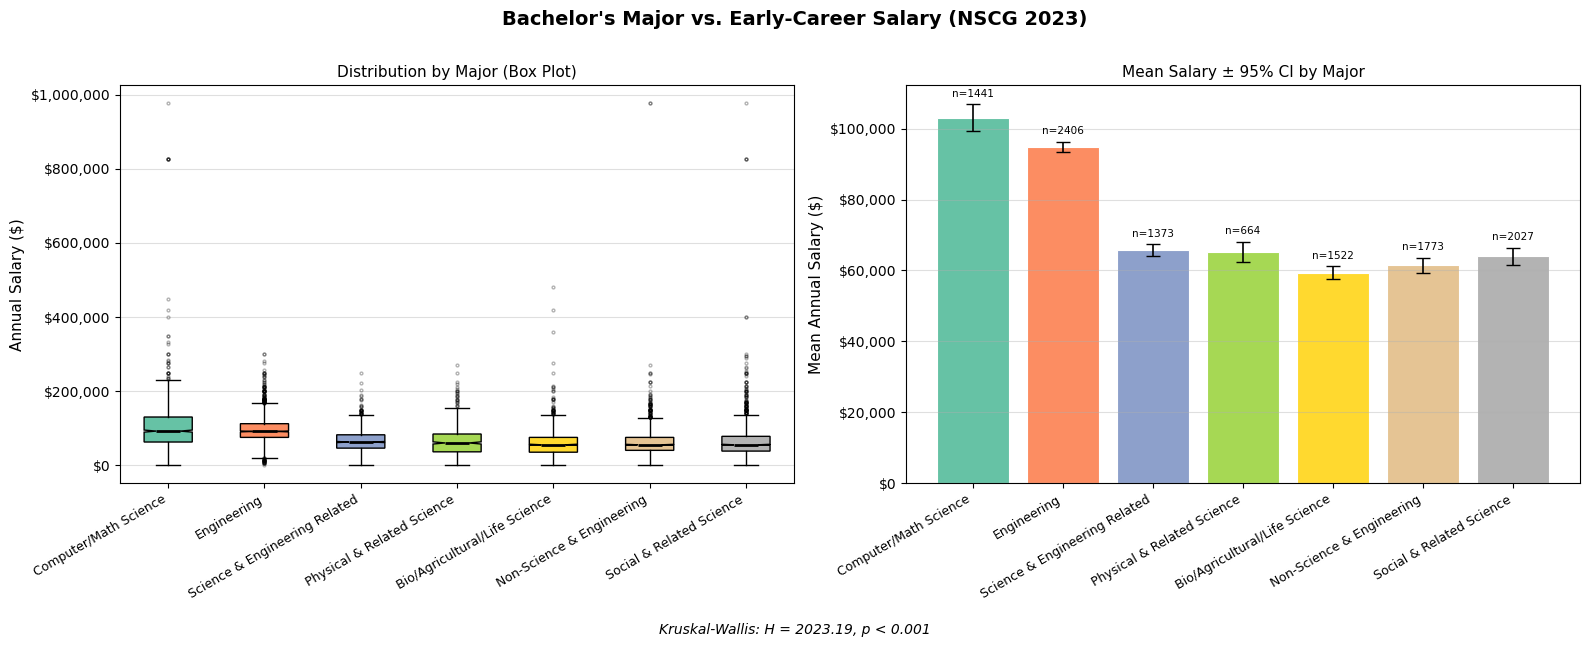

In [6]:
## EDA2 Plot:
## Box Plot + Mean +/- 95% CI bar chart

order = (
    df_eda2.groupby('Major_Category')['SALARY']
         .median()
         .sort_values(ascending=False)
         .index.tolist()
)

colors = plt.cm.Set2(np.linspace(0, 1, len(order)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Bachelor's Major vs. Early-Career Salary (NSCG 2023)",
             fontsize=14, fontweight='bold', y=1.01)

# Box plot
data_ordered = [df_eda2[df_eda2['Major_Category'] == m]['SALARY'].dropna() for m in order]
bp = axes[0].boxplot(
    data_ordered, 
    patch_artist=True, 
    notch=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_xticklabels(order, rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('Annual Salary ($)', fontsize=11)
axes[0].set_title('Distribution by Major (Box Plot)', fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(axis='y', alpha=0.4)

## Bar chart with mean +/- 95% CI
summary = (df_eda2.groupby('Major_Category')['SALARY']
           .agg(['mean', 'sem', 'count'])
           .loc[order])
summary['ci95'] = 1.96 * summary['sem']


axes[1].bar(
    range(len(order)),
    summary['mean'],
    yerr=summary['ci95'], 
    capsize=5,
    color=colors, 
    edgecolor='white', 
    linewidth=0.8,
    error_kw=dict(ecolor='black', elinewidth=1.2)
)
axes[1].set_xticks(range(len(order)))
axes[1].set_xticklabels(order, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Mean Annual Salary ($)', fontsize=11)
axes[1].set_title('Mean Salary ± 95% CI by Major', fontsize=11)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].grid(axis='y', alpha=0.4)

for i, (_, row) in enumerate(summary.iterrows()):
    axes[1].text(i, row['mean'] + row['ci95'] + 1500,
                 f"n={int(row['count'])}", ha='center', va='bottom', fontsize=7.5)

stat_note = f"Kruskal-Wallis: H = {h_stat:.2f}, p {'< 0.001' if p_val < 0.001 else f'= {p_val:.4f}'}"
fig.text(0.5, -0.03, stat_note, ha='center', fontsize=10, style='italic')
plt.tight_layout()
os.makedirs('../results/EDA2_figs', exist_ok=True)
plt.savefig('../results/EDA2_figs/major_vs_salary.png', dpi=150, bbox_inches='tight')
plt.show()

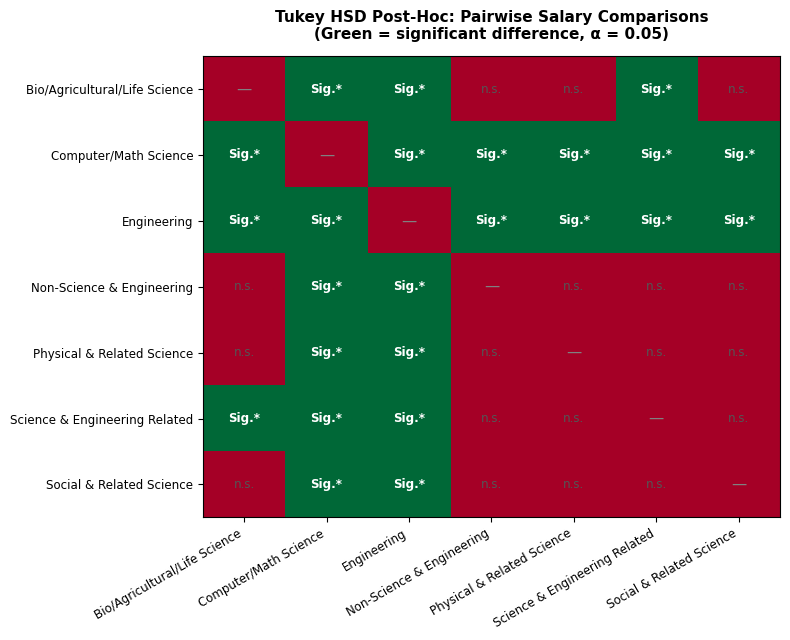

In [7]:
## EDA2 Plot:
## Tukey HSD significance heatmap

groups_u = sorted(df_eda2['Major_Category'].unique())
n = len(groups_u)
idx = {g: i for i, g in enumerate(groups_u)}
reject_matrix = np.zeros((n, n))
for row in tukey.summary().data[1:]:
    g1, g2 = row[0], row[1]
    reject_matrix[idx[g1], idx[g2]] = 1 if row[6] == True else 0
    reject_matrix[idx[g2], idx[g1]] = 1 if row[6] == True else 0

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.imshow(reject_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

for i in range(n):
    for j in range(n):
        if i == j:
            ax.text(j, i, '—', ha='center', va='center', fontsize=11, color='gray')
        else:
            sig = reject_matrix[i, j]
            txt = 'Sig.*' if sig else 'n.s.'
            col = 'white' if sig else '#555'
            ax.text(j, i, txt, ha='center', va='center', fontsize=8.5,
                    fontweight='bold' if sig else 'normal', color=col)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(groups_u, fontsize=8.5, rotation=30, ha='right')
ax.set_yticklabels(groups_u, fontsize=8.5)
ax.set_title("Tukey HSD Post-Hoc: Pairwise Salary Comparisons\n(Green = significant difference, α = 0.05)",
             fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()

os.makedirs('../results/EDA2_figs', exist_ok=True)
plt.savefig('../results/EDA2_figs/tukeyhst_post-salary-comparisons.png', dpi=150, bbox_inches='tight')
plt.show()